In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("../raw_datasets/Time_Series_Forcasting.csv")
df.head()

,Date,Product_ID,Product_Category,Region,Units_Sold,Revenue,Marketing_Spend,Holiday_Indicator,Temperature,Fuel_Price,Consumer_Confidence,Season,Forecast_Demand
0,0,151,4,0,41.0,1350.547197,8329.692645,0,25.802048,1.639941,61.649396,3,219.78
1,1,192,4,3,40.0,4876.262658,1265.543733,0,23.219427,1.537321,107.181574,3,101.53
2,2,114,1,2,44.0,7581.268018,2713.123264,0,28.996953,1.265711,112.250104,3,121.32
3,3,171,3,2,23.0,4550.806769,3531.816820,0,26.620706,1.177090,91.048355,3,125.91
4,4,160,0,1,54.0,7871.611836,9327.608513,0,11.844271,1.853644,89.221604,3,264.60


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 10000 non-null  int64  
 1   Product_ID           10000 non-null  int64  
 2   Product_Category     10000 non-null  int64  
 3   Region               10000 non-null  int64  
 4   Units_Sold           10000 non-null  float64
 5   Revenue              10000 non-null  float64
 6   Marketing_Spend      10000 non-null  float64
 7   Holiday_Indicator    10000 non-null  int64  
 8   Temperature          10000 non-null  float64
 9   Fuel_Price           10000 non-null  float64
 10  Consumer_Confidence  10000 non-null  float64
 11  Season               10000 non-null  int64  
 12  Forecast_Demand      10000 non-null  float64
dtypes: float64(7), int64(6)
memory usage: 1015.8 KB


<Axes: >

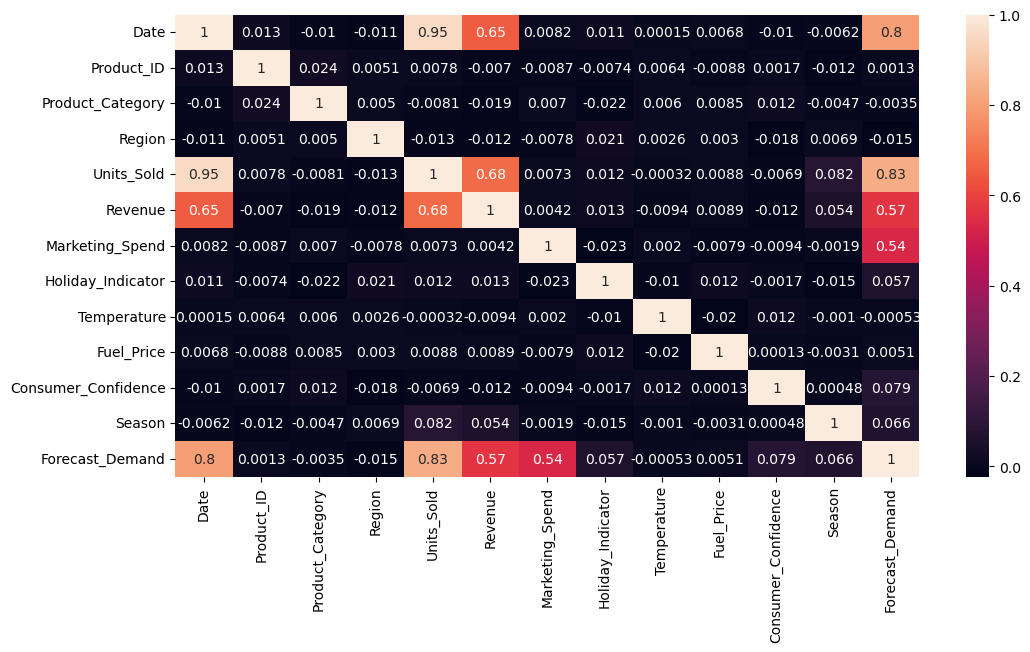

In [6]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.corr(), annot=True)

In [8]:
df.nunique()

Date                   10000
Product_ID               100
Product_Category           5
Region                     4
Units_Sold               578
Revenue                 9997
Marketing_Spend        10000
Holiday_Indicator          2
Temperature            10000
Fuel_Price             10000
Consumer_Confidence    10000
Season                     4
Forecast_Demand         8750
dtype: int64

In [7]:
df.columns

Index(['Date', 'Product_ID', 'Product_Category', 'Region', 'Units_Sold',
       'Revenue', 'Marketing_Spend', 'Holiday_Indicator', 'Temperature',
       'Fuel_Price', 'Consumer_Confidence', 'Season', 'Forecast_Demand'],
      dtype='object')

In [11]:
features=[
    'Units_Sold',
    'Revenue', 
    'Marketing_Spend', 
    'Holiday_Indicator',  
    'Season', 
    'Forecast_Demand'
]

<Axes: >

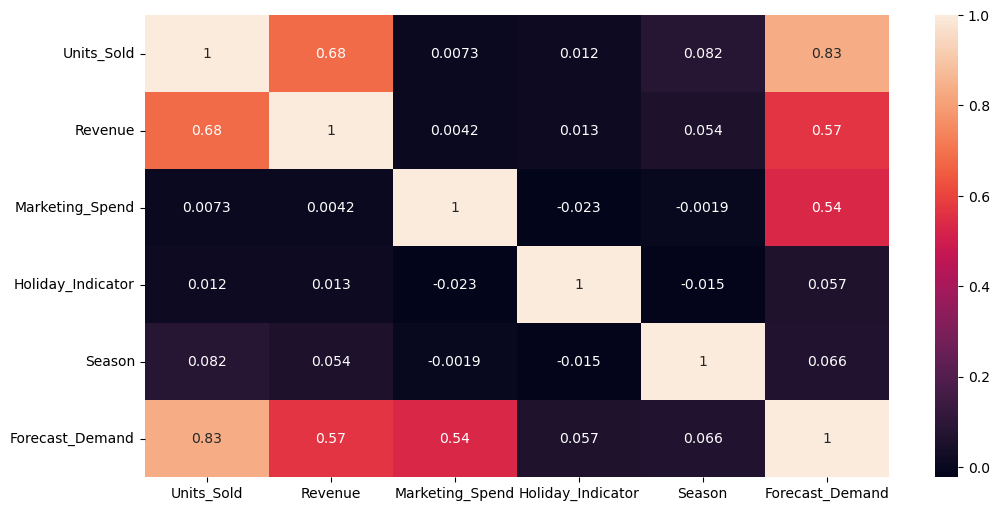

In [12]:
plt.figure(figsize=(12, 6))
sns.heatmap(df[features].corr(), annot=True)

In [13]:
x=df[features].drop('Forecast_Demand', axis=1)
y=df['Forecast_Demand']

In [14]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [15]:
x.head()

,Units_Sold,Revenue,Marketing_Spend,Holiday_Indicator,Season
0,41.0,1350.547197,8329.692645,0,3
1,40.0,4876.262658,1265.543733,0,3
2,44.0,7581.268018,2713.123264,0,3
3,23.0,4550.806769,3531.816820,0,3
4,54.0,7871.611836,9327.608513,0,3


In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [18]:
# linear regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train_scaled, y_train)
y_pred_lr= lr.predict(x_test_scaled)
y_train_pred_lr = lr.predict(x_train_scaled)

In [19]:
# decision tree regressor
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(x_train_scaled, y_train)
y_pred_dt = dt.predict(x_test_scaled)
y_train_pred_dt = dt.predict(x_train_scaled)

In [20]:
# random forest regressor
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(x_train_scaled, y_train)
y_pred_rf = rf.predict(x_test_scaled)
y_train_pred_rf = rf.predict(x_train_scaled)

In [21]:
from sklearn.metrics import r2_score
print("Linear Regression train R2 Score:", r2_score(y_train, y_train_pred_lr))
print("Linear Regression test R2 Score:", r2_score(y_test, y_pred_lr))
print("Decision Tree train R2 Score:", r2_score(y_train, y_train_pred_dt))
print("Decision Tree test R2 Score:", r2_score(y_test, y_pred_dt))
print("Random Forest train R2 Score:", r2_score(y_train, y_train_pred_rf))
print("Random Forest test R2 Score:", r2_score(y_test, y_pred_rf))


Linear Regression train R2 Score: 0.9813542406092193
Linear Regression test R2 Score: 0.980891659792441
Decision Tree train R2 Score: 1.0
Decision Tree test R2 Score: 0.9554658294997018
Random Forest train R2 Score: 0.9968003601288199
Random Forest test R2 Score: 0.9761711261558668


In [23]:
df[features].to_csv("../processed_datasets/processed_product_demand_forcasting.csv", index=False)